In [216]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
from environments import CorridorEnvTerminalReward
from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [281]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_hidden, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        return self.layer2(x)

In [365]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)
ALPHA = 1e-4
GAMMA = 0.95
BATCH_SIZE = 8
EPSILON = 0.01
N_EPISODES = 50
TAU = 1.0

n_hidden = 64

dqn = DQN(1, n_hidden, n_actions)

optimizer = optim.AdamW(dqn.parameters(), lr=ALPHA, amsgrad=True)
memory = ReplayMemory(10000)

In [366]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [367]:
def deep_q_learning(epsilon: float = 0.1, gamma: float = 1.0, num_episodes: int = 10):
    
    err = []
    optimal_pi = [[0, 0, 1]]*n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)
    
    for e in range(num_episodes):
        done = False
        s = torch.tensor(np.random.randint(0,env.nS), dtype=torch.float32, device=device).unsqueeze(0)
        G = 0
        while not done:
            with torch.no_grad():
                q_s = dqn(s)
            a = epsilon_greedy_policy(q_s, epsilon = epsilon)
            [_, s_, r, done] = env.step(s, a)[0]

            # Store the transition in memory
            s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            a = torch.tensor(a, dtype=torch.int64, device=device).unsqueeze(0)
            r = torch.tensor(r, dtype=torch.float32, device=device).unsqueeze(0)
            s_ = torch.tensor(s_, dtype=torch.float32, device=device).unsqueeze(0)
            memory.push(s, a, s_, r)

            s = s_.squeeze(0)
            if len(memory) < BATCH_SIZE:
                continue
            transitions = memory.sample(BATCH_SIZE)
            batch = Transition(*zip(*transitions))

            non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
            non_final_s = [s for s in batch.next_state if s is not None]
            non_final_next_states = torch.cat(non_final_s)
            state_batch = torch.cat(batch.state)
            action_batch = torch.cat(batch.action)
            reward_batch = torch.cat(batch.reward)
            
            # print("action batch", action_batch.unsqueeze(1).shape)
            # print("reward batch", reward_batch.unsqueeze(1).shape)
            q_s = dqn(state_batch).gather(1, action_batch.unsqueeze(1))

            q_s_next = torch.zeros(BATCH_SIZE, device=device)
            with torch.no_grad():
                q_s_next[non_final_mask] = dqn(non_final_next_states).max(1)[0]

            # Compute the expected Q values
            target = (q_s_next * gamma) + reward_batch

            # Compute Huber loss
            criterion = nn.SmoothL1Loss()
            loss = criterion(q_s, target.unsqueeze(1))

            # Optimize the model
            optimizer.zero_grad()
            loss.backward()
            # In-place gradient clipping
            torch.nn.utils.clip_grad_value_(dqn.parameters(), 100)
            optimizer.step()
            
        qs = [dqn(torch.tensor([s], dtype=torch.float32, device=device)) for s in range(n_states)]
        v = [float(q.max().detach().cpu()) for q in qs]
        # print("Episode", e, v)
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

In [346]:
v, err = deep_q_learning(epsilon=EPSILON, gamma=GAMMA, num_episodes=N_EPISODES)

/tmp/ipykernel_22/746930565.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
/tmp/ipykernel_22/746930565.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_ = torch.tensor(s_, dtype=torch.float32, device=device).unsqueeze(0)


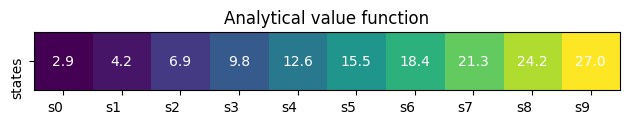

In [347]:
annotated_heatmap([v], "Analytical value function")

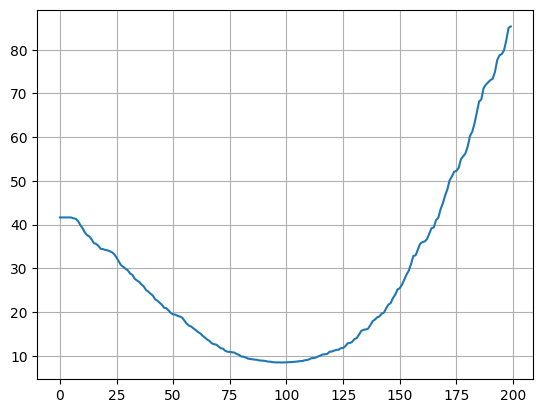

In [348]:
plt.grid()
plt.plot(err, label="alpha:"+str(round(ALPHA, 2)))

In [368]:
def deep_q_learning(epsilon: float = 0.1, gamma: float = 1.0, num_episodes: int = 10):
    
    err = []
    optimal_pi = [[0, 0, 1]]*n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)
    policy_dqn = DQN(1, n_hidden, n_actions)
    target_dqn = DQN(1, n_hidden, n_actions)
    target_dqn.load_state_dict(policy_dqn.state_dict())
    
    for e in range(num_episodes):
        done = False
        s = torch.tensor(np.random.randint(0,env.nS), dtype=torch.float32, device=device).unsqueeze(0)
        G = 0
        while not done:
            with torch.no_grad():
                q_s = policy_dqn(s)
            a = epsilon_greedy_policy(q_s, epsilon = epsilon)
            [_, s_, r, done] = env.step(s, a)[0]

            # Store the transition in memory
            s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            a = torch.tensor(a, dtype=torch.int64, device=device).unsqueeze(0)
            r = torch.tensor(r, dtype=torch.float32, device=device).unsqueeze(0)
            s_ = torch.tensor(s_, dtype=torch.float32, device=device).unsqueeze(0)
            memory.push(s, a, s_, r)

            s = s_.squeeze(0)
            if len(memory) < BATCH_SIZE:
                continue
            transitions = memory.sample(BATCH_SIZE)
            batch = Transition(*zip(*transitions))

            non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
            non_final_s = [s for s in batch.next_state if s is not None]
            non_final_next_states = torch.cat(non_final_s)
            state_batch = torch.cat(batch.state)
            action_batch = torch.cat(batch.action)
            reward_batch = torch.cat(batch.reward)
            
            # print("action batch", action_batch.unsqueeze(1).shape)
            # print("reward batch", reward_batch.unsqueeze(1).shape)
            q_s = policy_dqn(state_batch).gather(1, action_batch.unsqueeze(1))

            q_s_next = torch.zeros(BATCH_SIZE, device=device)
            with torch.no_grad():
                q_s_next[non_final_mask] = target_dqn(non_final_next_states).max(1)[0]

            # Compute the expected Q values
            target = (q_s_next * gamma) + reward_batch

            # Compute Huber loss
            criterion = nn.SmoothL1Loss()
            loss = criterion(q_s, target.unsqueeze(1))

            # Optimize the model
            optimizer.zero_grad()
            loss.backward()
            # In-place gradient clipping
            torch.nn.utils.clip_grad_value_(policy_dqn.parameters(), 100)
            optimizer.step()

            target_net_state_dict = target_dqn.state_dict()
            policy_net_state_dict = policy_dqn.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
            target_dqn.load_state_dict(target_net_state_dict)
            
        qs = [policy_dqn(torch.tensor([s], dtype=torch.float32, device=device)) for s in range(n_states)]
        v = [float(q.max().detach().cpu()) for q in qs]
        # print("Episode", e, v)
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

In [ ]:
v, err = deep_q_learning(epsilon=EPSILON, gamma=GAMMA, num_episodes=N_EPISODES)

/tmp/ipykernel_22/93041241.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
/tmp/ipykernel_22/93041241.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_ = torch.tensor(s_, dtype=torch.float32, device=device).unsqueeze(0)


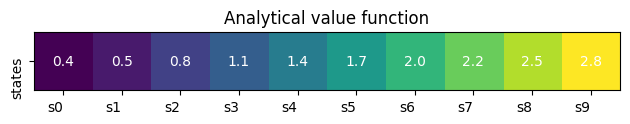

In [357]:
annotated_heatmap([v], "Analytical value function")

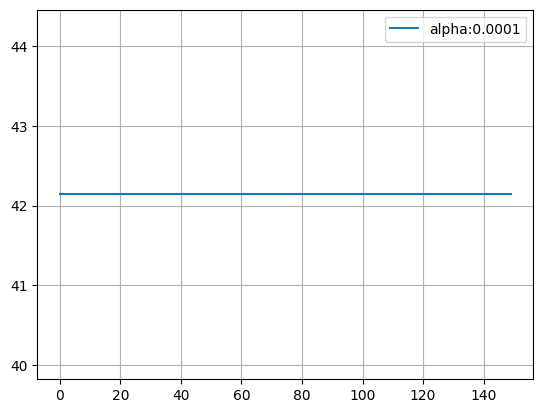

In [361]:
plt.grid()
plt.plot(err, label="alpha:"+str(round(ALPHA, 4)))
plt.legend()